In [57]:
# --- One cell: same code for Snowflake Notebook and local Jupyter ---
# --- Test

from snowflake.snowpark import Session
import os

# Edit these once (used for local fallback + context standardization)
SF = {
    "account": "SFCOGSOPS-SNOWHOUSE_AWS_US_WEST_2",
    "user": "AALUSI",
    "authenticator": "externalbrowser",
    "warehouse": "AGAVIC_WH",
    "role": "PUBLIC",
    "database": "SNOWPUBLIC",
    "schema": "NOTEBOOKS",
}

def get_session():
    # 1) Try Snowflake Notebook session
    try:
        from snowflake.snowpark.context import get_active_session
        s = get_active_session()
        # Probe: if we can run a trivial query, it's real; otherwise fall back
        try:
            s.sql("SELECT 1").collect()
            return s
        except Exception:
            pass
    except Exception:
        pass

    # 2) Local Jupyter fallback
    return Session.builder.configs(SF).create()

session = get_session()

# Standardize context (applies in both environments)
for cmd in (
    f"USE ROLE {SF['role']}",
    f"USE WAREHOUSE {SF['warehouse']}",
    f"USE DATABASE {SF['database']}",
    f"USE SCHEMA {SF['schema']}",
):
    try:
        session.sql(cmd).collect()
    except Exception as e:
        print(f"⚠️ {cmd} -> {e}")

# Smoke check
session.sql(
    "SELECT current_role() role, current_warehouse() wh, current_database() db, current_schema() sch"
).show()

-----------------------------------------------
|"ROLE"  |"WH"       |"DB"        |"SCH"      |
-----------------------------------------------
|PUBLIC  |AGAVIC_WH  |SNOWPUBLIC  |NOTEBOOKS  |
-----------------------------------------------



In [58]:
%pip install pandas pyarrow
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [59]:

df = session.sql("SELECT * FROM samples.tickit.sales LIMIT 1000").to_pandas()
df.head()

,SALESID,LISTID,SELLERID,BUYERID,EVENTID,DATEID,QTYSOLD,PRICEPAID,COMMISSION,SALETIME
0,1,1,36861,21191,7872,1875,4,728.0,109.20,2008-02-18 02:36:48
1,2,4,8117,11498,4337,1983,2,76.0,11.40,2008-06-06 05:00:16
2,3,5,1616,17433,8647,1983,2,350.0,52.50,2008-06-06 08:26:17
3,4,5,1616,19715,8647,1986,1,175.0,26.25,2008-06-09 08:38:52
4,5,6,47402,14115,8240,2069,2,154.0,23.10,2008-08-31 09:17:02


📊 Daily summary:


,SALE_DATE,orders,qty,gross,net
0,2008-01-05,1,4,188.0,159.80
1,2008-01-09,2,4,472.0,401.20
2,2008-01-13,1,2,258.0,219.30
3,2008-01-15,1,2,472.0,401.20
4,2008-01-16,1,1,247.0,209.95
5,2008-01-17,2,5,762.0,647.70
6,2008-01-18,2,3,255.0,216.75
7,2008-01-19,2,2,93.0,79.05
8,2008-01-21,2,4,792.0,673.20
9,2008-01-23,3,9,907.0,770.95



🏷️  Top sellers (by gross):


,SELLERID,orders,qty,gross,net,avg_unit_price
0,24502,4,10,2160.0,1836.00,216.0
1,7764,4,10,2130.0,1810.50,213.0
2,40931,4,10,2070.0,1759.50,207.0
3,18520,4,10,2030.0,1725.50,203.0
4,5298,3,9,2025.0,1721.25,225.0
5,24858,4,10,1970.0,1674.50,197.0
6,23902,3,9,1953.0,1660.05,217.0
7,38104,4,12,1932.0,1642.20,161.0
8,22351,3,7,1701.0,1445.85,243.0
9,42137,3,7,1701.0,1445.85,243.0



🎫  Top events (by gross):


,EVENTID,orders,qty,gross,net
0,403,6,13,2736.0,2325.60
1,2906,6,13,2196.0,1866.60
2,2784,4,10,2160.0,1836.00
3,6585,4,10,2130.0,1810.50
4,4708,4,10,2030.0,1725.50
5,1631,3,9,2025.0,1721.25
6,3375,4,10,1970.0,1674.50
7,4722,3,9,1953.0,1660.05
8,1335,4,12,1932.0,1642.20
9,6685,5,10,1909.0,1622.65



🔗 Correlation (Qty vs Unit Price): -0.005


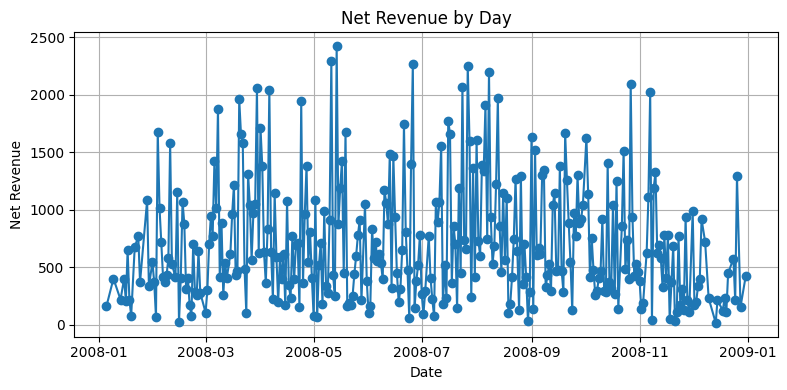

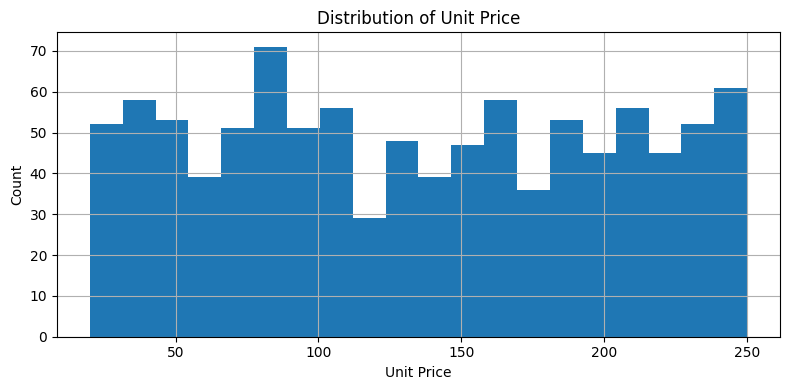

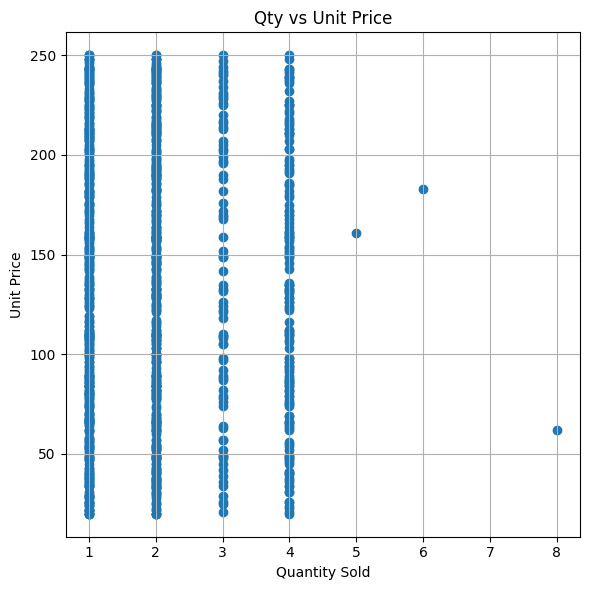


📅 Weekly summary:


,WEEK_START,orders,qty,gross,net
0,2007-12-31,1,4,188.0,159.80
1,2008-01-07,3,6,730.0,620.50
2,2008-01-14,8,13,1829.0,1554.65
3,2008-01-21,7,17,2133.0,1813.05
4,2008-01-28,21,40,4802.0,4081.70
5,2008-02-04,24,49,6020.0,5117.00
6,2008-02-11,19,32,4230.0,3595.50
7,2008-02-18,16,30,3346.0,2844.10
8,2008-02-25,10,19,1862.0,1582.70
9,2008-03-03,28,66,8429.0,7164.65


In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---- 0) Copy + basic dtype cleanup ----
df2 = df.copy()

# Ensure correct types (safe even if already correct)
for col in ["QTYSOLD", "PRICEPAID", "COMMISSION"]:
    df2[col] = pd.to_numeric(df2[col], errors="coerce")
df2["SALETIME"] = pd.to_datetime(df2["SALETIME"], errors="coerce")

# ---- 1) Derived fields ----
df2["GROSS_SALE"] = df2["PRICEPAID"]                    # total paid
df2["NET_SALE"]   = df2["PRICEPAID"] - df2["COMMISSION"]# after commission
df2["UNIT_PRICE"] = df2["PRICEPAID"] / df2["QTYSOLD"]
df2["SALE_DATE"]  = df2["SALETIME"].dt.date
df2["WEEK_START"] = df2["SALETIME"].dt.to_period("W").dt.start_time

# ---- 2) Core summaries (display these) ----
daily = (df2.groupby("SALE_DATE")
           .agg(orders=("SALESID","count"),
                qty=("QTYSOLD","sum"),
                gross=("GROSS_SALE","sum"),
                net=("NET_SALE","sum"))
           .reset_index())

top_sellers = (df2.groupby("SELLERID")
                 .agg(orders=("SALESID","count"),
                      qty=("QTYSOLD","sum"),
                      gross=("GROSS_SALE","sum"),
                      net=("NET_SALE","sum"),
                      avg_unit_price=("UNIT_PRICE","mean"))
                 .sort_values("gross", ascending=False)
                 .head(10)
                 .reset_index())

top_events = (df2.groupby("EVENTID")
                .agg(orders=("SALESID","count"),
                     qty=("QTYSOLD","sum"),
                     gross=("GROSS_SALE","sum"),
                     net=("NET_SALE","sum"))
                .sort_values("gross", ascending=False)
                .head(10)
                .reset_index())

price_qty_corr = df2[["QTYSOLD","UNIT_PRICE"]].corr().loc["QTYSOLD","UNIT_PRICE"]

print("📊 Daily summary:")
display(daily.head(10))

print("\n🏷️  Top sellers (by gross):")
display(top_sellers)

print("\n🎫  Top events (by gross):")
display(top_events)

print(f"\n🔗 Correlation (Qty vs Unit Price): {price_qty_corr:.3f}")

# ---- 3) Quick charts (matplotlib; no seaborn) ----

# 3a) Net revenue over time
plt.figure(figsize=(8,4))
plt.plot(daily["SALE_DATE"], daily["net"], marker="o")
plt.title("Net Revenue by Day")
plt.xlabel("Date")
plt.ylabel("Net Revenue")
plt.grid(True)
plt.tight_layout()
plt.show()

# 3b) Distribution of unit prices
plt.figure(figsize=(8,4))
df2["UNIT_PRICE"].dropna().plot(kind="hist", bins=20)
plt.title("Distribution of Unit Price")
plt.xlabel("Unit Price")
plt.ylabel("Count")
plt.grid(True)
plt.tight_layout()
plt.show()

# 3c) Quantity vs Unit Price scatter
plt.figure(figsize=(6,6))
plt.scatter(df2["QTYSOLD"], df2["UNIT_PRICE"])
plt.title("Qty vs Unit Price")
plt.xlabel("Quantity Sold")
plt.ylabel("Unit Price")
plt.grid(True)
plt.tight_layout()
plt.show()

# ---- 4) Optional: weekly view (nice for longer series) ----
weekly = (df2.groupby("WEEK_START")
            .agg(orders=("SALESID","count"),
                 qty=("QTYSOLD","sum"),
                 gross=("GROSS_SALE","sum"),
                 net=("NET_SALE","sum"))
            .reset_index())
print("\n📅 Weekly summary:")
display(weekly.head(10))

In [61]:
!pip freeze > requirements.txt